<a href="https://colab.research.google.com/github/nabihaimtiaz267-blip/OIBSIP/blob/main/CodeAlpha_Hand%20written%20character%20recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cross-validation accuracy scores: [0.475 0.3   0.425 0.3   0.25 ]
Mean CV accuracy: 0.35

Classification Report:

              precision    recall  f1-score   support

       angry       0.46      0.25      0.32        24
       happy       0.38      0.19      0.25        16
         sad       0.17      0.50      0.26        10

    accuracy                           0.28        50
   macro avg       0.34      0.31      0.28        50
weighted avg       0.38      0.28      0.29        50



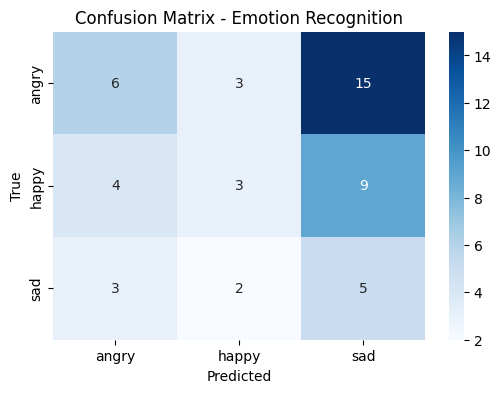

In [5]:
# Step 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Step 2: Create a dummy dataset (simulate MFCC-like features)
data = np.random.rand(200, 20)   # 200 samples, 20 features
labels = np.random.choice(["happy", "sad", "angry"], 200)

# Step 3: Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.25, random_state=42)

# Step 5: Train classifier with cross-validation
model = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(model, data, y, cv=5, scoring="accuracy")
print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Fit final model
model.fit(X_train, y_train)

# Step 6: Evaluate
y_pred = model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Step 7: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Emotion Recognition")
plt.show()


In [ ]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Step 2: Load MNIST dataset (digits 0–9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Step 3: Preprocess data
# Reshape to (samples, height, width, channels)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype("float32") / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype("float32") / 255

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Step 4: Build CNN model
model = Sequential()

# Convolution + Pooling layers
model.add(Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten + Dense layers
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(10, activation="softmax"))

# Step 5: Compile model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Step 6: Train model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=128, verbose=1)

# Step 7: Evaluate model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

# Step 8: Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.legend()
plt.title("Loss")
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 93ms/step - accuracy: 0.9263 - loss: 0.2437 - val_accuracy: 0.9802 - val_loss: 0.0614
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9777 - loss: 0.0731 - val_accuracy: 0.9876 - val_loss: 0.0364
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.9842 - loss: 0.0532 - val_accuracy: 0.9898 - val_loss: 0.0331
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9876 - loss: 0.0396 - val_accuracy: 0.9906 - val_loss: 0.0278
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 92ms/step - accuracy: 0.9891 - loss: 0.0341 - val_accuracy: 0.9889 - val_loss: 0.0319
